# Week 2 Assignment: Reducing overfitting

## Task Description

Task is to build a neural network with california housing dataset. First goal is to try different model architectures and produce a model that clearly overfits the training data. Then different regularization techniques will be applied to reduce the overfitting and improve the model's generalization performance.

The large version of the california housing dataset from `keras.datasets` will be used for this assignment. This dataset contains 20,640 samples with 8 numerical features and a target variable representing the median house value. The dataset is split into a training set (80%) and a test set (20%). On top of the train and test split, we will further split the training set into a smaller training set and a validation set to monitor the model's performance during training and to help identify overfitting.

In [8]:
import time

import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils import shuffle
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.utils import to_categorical
from keras.losses import MeanAbsoluteError
from keras.callbacks import EarlyStopping
from keras.layers import Dropout

from keras.datasets import california_housing

(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large', test_split=0.2)
print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


## Data Preprocessing

For data preprocessing, we will first split the training data into a smaller training set and a validation set. This allows us to monitor the model's performance on unseen data during training and helps us identify when the model starts to overfit. We will use an 80-20 split for the training and validation sets. Finally we will normalize the input features by standardizing them (subtracting the mean and dividing by the standard deviation) and scale down the target variable by dividing it by 100,000 to make it more manageable for the neural network.

In [10]:
# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

Splitting the training data into a smaller training set and a validation set is done using array slicing. This gives us training set with 13,209 samples and a validation set with 3,303 samples.

In [11]:
# Split training data into smaller training set and validation set
train_size = int(0.8 * inputs.shape[0])
x_train = inputs[:train_size]
y_train = targets[:train_size]
x_val = inputs[train_size:]
y_val = targets[train_size:]
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(13209, 8) (13209,)
(3303, 8) (3303,)


Now I will standardize the input features by subtracting the mean and dividing by the standard deviation. We will only compute the mean and standard deviation from the training set to avoid data leakage. We will also divide the target variable by 100,000 to scale it down to a more manageable range for the neural network. This is a common practice when dealing with regression problems where the target variable can have large values, as it helps improve the training stability and convergence of the model.

In [12]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std
x_val = (x_val - mean) / std

y_train = y_train / 100000.0
y_test = y_test / 100000.0
y_val = y_val / 100000.0

## Building a Neural Network that Overfits

For the first part of the assignment, we will build a neural network with a large capacity that is likely to overfit the training data. The model architecture consists of an input layer that matches the number of features (8), followed by 3 hidden layers with 256 neurons in each using the ReLU activation function. The output layer has a single neuron without an activation function since this is a regression problem. Model is using the Adam optimizer and mean squared error (MSE) as the loss function, along with mean absolute error (MAE) as a metric to monitor during training.

I tried few different architectures and found that this configuration with 3 hidden layers having 256 neurons in each, showed clear signs of overfitting with the validation loss curve starting to increase clearly after 50 epochs. I chose this architecture since it showed clear curve of overfitting while not being too extreme, which allowed me to see the effect of regularization techniques more clearly in the next part of the assignment.

Some of the architectures I experimented with include (experimentations were done with 100 epochs):
- Model with 2 hidden layers (64 and 64 neurons): After training, the validation loss curve stayed relatively flat during 100 epochs, indicating that the model was not overfitting as much.
- Model with 4 hidden layers (512, 256, 128, and 64 neurons): After training, the validation loss curve started showed a alot of zig-zag pattern, but not too much increasing trend, indicating that the model was not overfitting. The training loss curve started to show some zig-zag pattern after around 20 epochs, which is a sign of the model struggling to fit the training data.
- Model with 2 hidden layers (256 and 256 neurons): After training, the validation loss curve started to do zig-zag pattern after around 40 epochs with a slightly increasing trend, indicating that the model was starting to overfit.
- Model with 3 hidden layers (64, 64, and 64 neurons): This model showed clear overfitting with the validation loss curve starting to increase before 20 epochs and increasing more steeply after around 60 epochs.

In [ ]:
# define the model architecture
model = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1)
])

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,145 (524.00 KB)

 Trainable params: 134,145 (524.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()

history = model.fit(x_train, y_train, epochs=300, batch_size=512, validation_data=(x_val, y_val), verbose=0)

end_time = time.time()
print(f'Training time: {end_time - start_time:.2f} seconds')

Training time: 55.82 seconds


Training the model in google colab took me a bit less than 1 minute. When viewing the training history, we can see that the training loss continues to decrease steadily until around 150 epochs, while the validation loss has a small spike at around 50 epochs. The validation loss decreases a bit after the spike but starts a rising trend before 100 epochs. This is a sign of the model starting to overfit.

Text(0, 0.5, 'Loss')

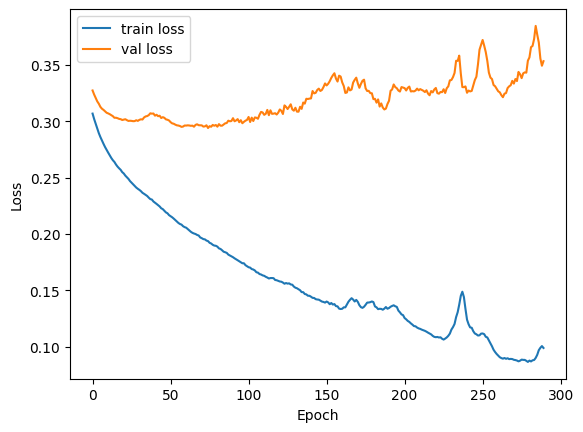

In [ ]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

## Evaluating the Model on the Test Set

Finally, I evaluated the model on the test set to see how well it performs on unseen data. Since the model is overfitting, I expected the test mean absolute error to be higher than the training mean absolute error. Training mean absolute error was looking really good at around 0.23 but the test mean absolute error was around 0.39, which is a significant increase and indicates that the model is not generalizing well to unseen data due to overfitting.

In [ ]:
# Test set evaluation
train_loss, train_mae = model.evaluate(x_train, y_train)
print(f'Train mean absolute error: {train_mae:.4f}')

test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1066 - mae: 0.2359
Train mean absolute error: 0.2359
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3522 - mae: 0.3958
Test mean absolute error: 0.3958


## Applying Regularization Techniques

Now that we have a model that clearly overfits the training data, the validation data has fulfilled its purpose of helping us identify the overfitting issue. We will proceed with combining the training and validation sets to create a larger training set, which will allow us to train the model on more data and potentially improve its generalization performance. After that, we will apply regularization techniques to reduce overfitting and improve the model's performance on unseen data.

The first thing we can try is to apply early stopping, which is a regularization technique that stops training when the validation loss starts to increase too much. Luckily, Keras provides a built-in callback for early stopping that we can easily use. We will set the `monitor` parameter to 'val_loss' to monitor the validation loss, and the `patience` parameter to 10, which means that training will stop if the validation loss does not improve for 10 consecutive epochs. This allows us to prevent the model from overfitting by stopping training at the point where the model starts to perform worse on the validation data.

In [13]:
# Concatenating training and validation datasets
x_train_full = np.concatenate((x_train, x_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

In [ ]:
# Defining early stopping to reduce overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

history = model.fit(x_train_full, y_train_full, epochs=300, batch_size=512, validation_split=0.2, callbacks=[early_stopping], verbose=0)

test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error with early stopping: {test_mae:.4f}')
print(f'Number of epochs trained with early stopping: {len(history.history["loss"])}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2934 - mae: 0.3609
Test mean absolute error with early stopping: 0.3609
Number of epochs trained with early stopping: 92


Early stopping successfully reduced the test mean absolute error from 0.39 to 0.36, which is not huge, but still noticable improvement since our target variable is scaled down by 100,000. It seems that the model trained for 92 epochs before early stopping kicked in, which is a significant reduction from the original 300 epochs, and it helped prevent the model from overfitting to the training data. Something worth noting is that the training stopped at around the point where I initially observed the validation loss starting to increase in the previous training history, which further confirms that early stopping is working as intended to prevent overfitting.

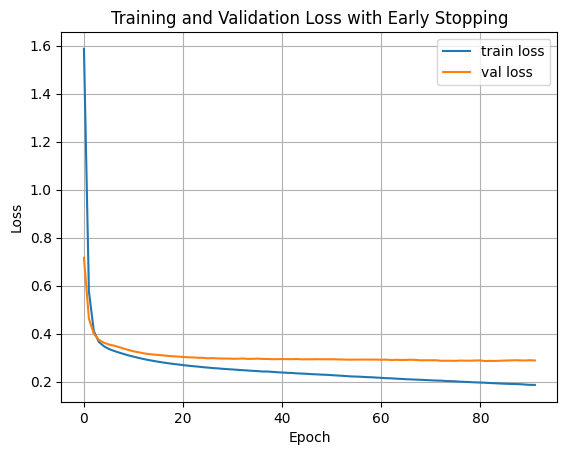

In [ ]:
# Plotting the training and validation loss curves for the model with early stopping
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Early Stopping')
plt.grid()
plt.show()

Next I experimented with L2 regularization, which adds a penalty term to the loss function. The L2 experiment showed similar results to early stopping, with a test mean absolute error of around 0.3757, which was a bit worse than the early stopping result.

In [ ]:
# Model with L2 regularization
from keras.regularizers import l2

model_l2 = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

model_l2.compile(optimizer='adam',loss='mse',metrics=['mae'])

history_l2 = model_l2.fit(x_train_full, y_train_full, epochs=300, batch_size=512, validation_split=0.2, verbose=0)

test_loss_l2, test_mae_l2 = model_l2.evaluate(x_test, y_test)
print(f'Test mean absolute error with L2 regularization: {test_mae_l2:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3535 - mae: 0.3757
Test mean absolute error with L2 regularization: 0.3757


Dropout method proved to be the most effective regularization technique in my testing. With dropout method I was able to achieve a test mean absolute error of around 0.3380, which is a significant improvement compared to the previous regularization techniques. I believe that the reason why dropout performed better than early stopping and L2 regularization in this case is that I have quite alot of neurons in the hidden layers (256 neurons in each of the 3 hidden layers), which can lead to a high capacity model that is more prone to overfitting. Dropout helps to mitigate this issue by randomly dropping out a fraction of the neurons during training, which forces the model to learn more robust features and reduces the chances of overfitting.

In [14]:
# Model with Dropout
model_dropout = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model_dropout.compile(optimizer='adam',loss='mse',metrics=['mae'])

history_dropout = model_dropout.fit(x_train_full, y_train_full, epochs=300, batch_size=512, validation_split=0.2, verbose=0)

test_loss_dropout, test_mae_dropout = model_dropout.evaluate(x_test, y_test)
print(f'Test mean absolute error with Dropout: {test_mae_dropout:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2622 - mae: 0.3380
Test mean absolute error with Dropout: 0.3380


Finally, in the code below I tried batch normalization. Suprisingly, batch normalization performed worse than the other regularization techniques. In fact, the test mean absolute error was actually higher than the original model without any regularization, which was quite unexpected. The batch normalization model had a test mean absolute error of around 0.41.

In [ ]:
# Model with batch normalization
from keras.layers import BatchNormalization

model_batchnorm = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

model_batchnorm.compile(optimizer='adam',loss='mse',metrics=['mae'])

history_batchnorm = model_batchnorm.fit(x_train_full, y_train_full, epochs=300, batch_size=512, validation_split=0.2, verbose=0)

test_loss_batchnorm, test_mae_batchnorm = model_batchnorm.evaluate(x_test, y_test)
print(f'Test mean absolute error with Batch Normalization: {test_mae_batchnorm:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3675 - mae: 0.4138
Test mean absolute error with Batch Normalization: 0.4138


Finally, I tried combining early stopping with dropout. I got satisfactory mean absolute error of around 0.3396, which is just slightly worse than the dropout only model, but still a significant improvement compared to the original model without regularization.

In [18]:
# Model with early stopping and dropout
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

model_combined = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1)
    ])

model_combined.compile(optimizer='adam',loss='mse',metrics=['mae'])

history_combined = model_combined.fit(x_train_full, y_train_full, epochs=300, batch_size=512, validation_split=0.2, callbacks=[early_stopping], verbose=0)

test_loss_combined, test_mae_combined = model_combined.evaluate(x_test, y_test)
print(f'Test mean absolute error with all regularization techniques combined: {test_mae_combined:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2613 - mae: 0.3396
Test mean absolute error with all regularization techniques combined: 0.3396


From the visualization of the training and validation loss curves we can see that combining early stopping with dropout helped the model train for longer without overfitting as the epochs went on past 200 mark. When trying out different combinations and configurations of regularization techniques, I found that using a combination of early stopping and dropout provided the best results in terms of test mean absolute error. I also noticed that I had to increase the patience parameter of early stopping to 30 when combining it with dropout. That is probably because dropout introduces more noise into the training process, which can cause the validation loss to fluctuate more. By increasing the patience, we allow the model to continue training for a longer period of time before early stopping kicks in, which can help the model find a better minimum in the loss landscape and improve generalization performance.

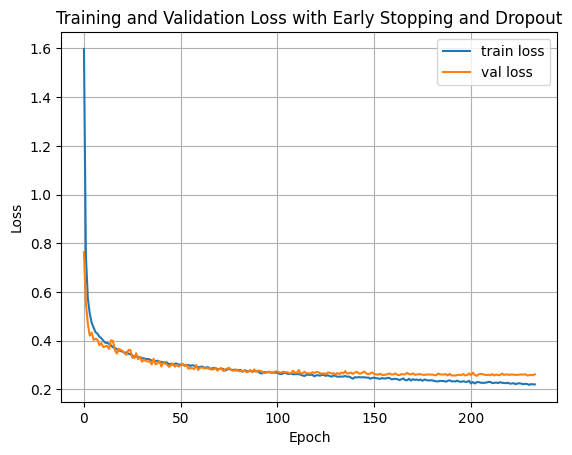

In [19]:
# Plotting the training and validation loss curves
plt.plot(history_combined.history['loss'], label='train loss')
plt.plot(history_combined.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Early Stopping and Dropout')
plt.grid()
plt.show()